In [1]:
import pandas as pd
import numpy as np

In [6]:
def calculate_financial_health_metrics(df, lookback_years=3):
    """
    Calculate financial health metrics for each company-year
    using lookback window of Y-3 to Y-1
    """
    results = []
    
    for company_id, company_data in df.groupby('company_id'):
        company_data = company_data.sort_values('financial_year_end')
        
        for idx, current_row in company_data.iterrows():
            current_year = current_row['financial_year_end']
            
            # Get lookback window: Y-3 to Y-1
            lookback_start = current_year - lookback_years
            lookback_end = current_year - 1
            
            lookback_data = company_data[
                (company_data['financial_year_end'] >= lookback_start) &
                (company_data['financial_year_end'] <= lookback_end)
            ]
            
            # Skip if we don't have enough lookback years
            if len(lookback_data) < lookback_years:
                continue
            
            # Calculate metrics from lookback period
            ocf_values = lookback_data['operating_cf'].dropna()
            
            if len(ocf_values) < 2:  # Need at least 2 values for volatility
                continue
            
            # 1. OCF positive count
            ocf_positive_count = (ocf_values > 0).sum()
            
            # 2. OCF volatility (standard deviation)
            ocf_volatility = ocf_values.std()
            
            # 3. Financing dependency flag
            # Check if company consistently relies on financing activities
            financing_cf_avg = lookback_data['financing_cf'].mean()
            financing_dependency = 1 if financing_cf_avg > 0 else 0
            
            # Assign label based on rules
            label = 0  # Default: Healthy
            
            # Risky conditions:
            # 1. More than half of OCF years are negative
            if ocf_positive_count < (len(ocf_values) / 2):
                label = 1
            # 2. High OCF volatility (more than 2x average OCF)
            elif ocf_volatility > (abs(ocf_values.mean()) * 2):
                label = 1
            # 3. Heavy financing dependency
            elif financing_dependency == 1 and financing_cf_avg > abs(ocf_values.mean()):
                label = 1
            
            result = {
                'company_id': company_id,
                'financial_year_end': current_year,
                'ocf_positive_count': ocf_positive_count,
                'ocf_volatility': ocf_volatility,
                'financing_dependency_flag': financing_dependency,
                'label': label,
                # Include original features for reference
                'operating_cf': current_row['operating_cf'],
                'investing_cf': current_row['investing_cf'],
                'financing_cf': current_row['financing_cf'],
                'total_assets': current_row['total_assets'],
                'revenue': current_row['revenue']
            }
            
            results.append(result)
    
    return pd.DataFrame(results)

In [5]:
input_path = "canonical_financials.csv"
output_path = "labeled_financials.csv"
df = pd.read_csv(input_path)

In [7]:
labeled_df = calculate_financial_health_metrics(df, lookback_years=3)

In [8]:
# Check overall label distribution
label_counts = labeled_df['label'].value_counts()
print(f"Total samples: {len(labeled_df)}")
print(f"Healthy (0): {label_counts.get(0, 0)} ({label_counts.get(0, 0)/len(labeled_df)*100:.1f}%)")
print(f"Risky (1): {label_counts.get(1, 0)} ({label_counts.get(1, 0)/len(labeled_df)*100:.1f}%)")

Total samples: 815
Healthy (0): 644 (79.0%)
Risky (1): 171 (21.0%)


In [9]:
# Compare feature distributions between healthy and risky companies
features_to_analyze = ['ocf_positive_count', 'ocf_volatility', 'financing_dependency_flag']

for feature in features_to_analyze:
    healthy_mean = labeled_df[labeled_df['label'] == 0][feature].mean()
    risky_mean = labeled_df[labeled_df['label'] == 1][feature].mean()
    print(f"{feature}: Healthy={healthy_mean:.2f}, Risky={risky_mean:.2f}")

ocf_positive_count: Healthy=2.94, Risky=1.07
ocf_volatility: Healthy=3568.83, Risky=12669.97
financing_dependency_flag: Healthy=0.21, Risky=0.86


In [10]:
# Analyze which factors dominate risky labels
risky_df = labeled_df[labeled_df['label'] == 1]

# Count how many risky cases are driven by each factor
negative_ocf_dominated = len(risky_df[risky_df['ocf_positive_count'] < 1.5])  # Less than 50% positive
high_volatility_dominated = len(risky_df[risky_df['ocf_volatility'] > risky_df['operating_cf'].abs() * 2])
financing_dependent = len(risky_df[risky_df['financing_dependency_flag'] == 1])

print(f"Risky cases dominated by negative OCF: {negative_ocf_dominated}")
print(f"Risky cases dominated by high volatility: {high_volatility_dominated}")
print(f"Risky cases with financing dependency: {financing_dependent}")

# Check overlap between factors
print(f"Cases with multiple risk factors: {len(risky_df[(risky_df['ocf_positive_count'] < 1.5) & (risky_df['financing_dependency_flag'] == 1)])}")

Risky cases dominated by negative OCF: 116
Risky cases dominated by high volatility: 35
Risky cases with financing dependency: 147
Cases with multiple risk factors: 103


In [11]:
from scipy import stats

# T-tests for continuous features
for feature in ['ocf_positive_count', 'ocf_volatility']:
    healthy = labeled_df[labeled_df['label'] == 0][feature].dropna()
    risky = labeled_df[labeled_df['label'] == 1][feature].dropna()
    t_stat, p_value = stats.ttest_ind(healthy, risky)
    print(f"{feature}: p-value = {p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''}")

# Chi-square test for categorical feature
contingency_table = pd.crosstab(labeled_df['label'], labeled_df['financing_dependency_flag'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Financing dependency chi-square: p-value = {p_value:.4f}")

ocf_positive_count: p-value = 0.0000 ***
ocf_volatility: p-value = 0.0000 ***
Financing dependency chi-square: p-value = 0.0000


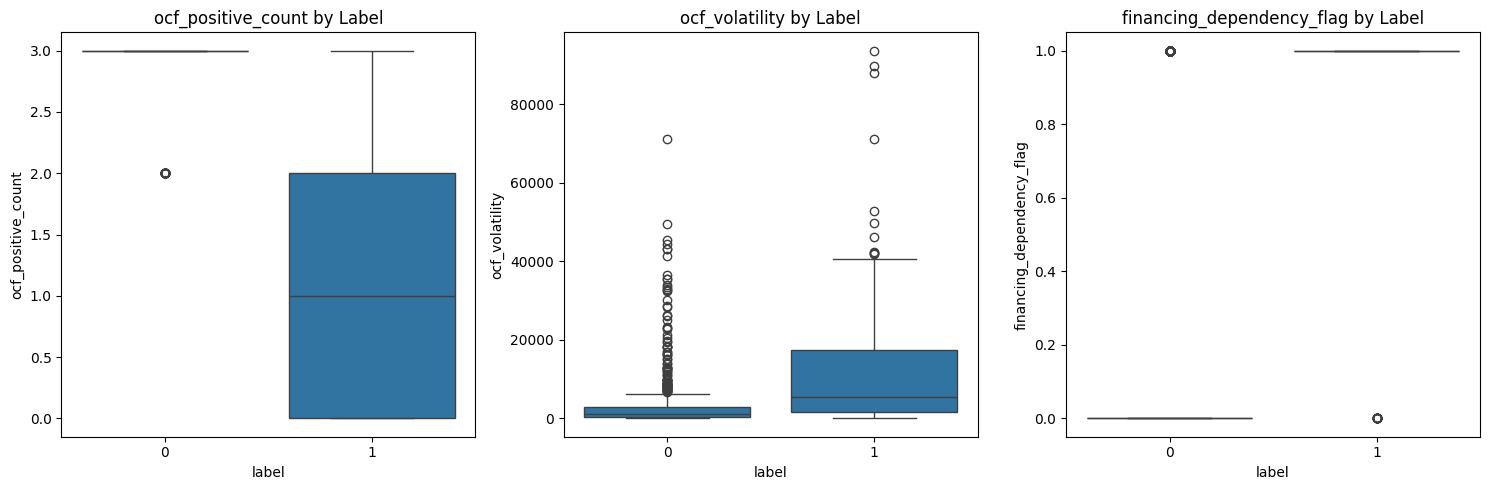

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution plots for each feature by label
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(['ocf_positive_count', 'ocf_volatility', 'financing_dependency_flag']):
    sns.boxplot(x='label', y=feature, data=labeled_df, ax=axes[i])
    axes[i].set_title(f'{feature} by Label')

plt.tight_layout()
plt.savefig('label_validation_plots.png')
plt.show()

In [13]:
# Examine extreme cases
most_risky = risky_df.nlargest(5, 'ocf_volatility')
print("Most volatile risky cases:")
print(most_risky[['company_id', 'financial_year_end', 'ocf_volatility', 'ocf_positive_count']])

most_financing_dependent = risky_df[risky_df['financing_dependency_flag'] == 1].nlargest(5, 'financing_cf')
print("\nMost financing-dependent risky cases:")
print(most_financing_dependent[['company_id', 'financial_year_end', 'financing_cf', 'operating_cf']])

Most volatile risky cases:
    company_id  financial_year_end  ocf_volatility  ocf_positive_count
634       SBIN                2024    93668.816713                   2
630       SBIN                2020    89840.445598                   2
629       SBIN                2019    88056.618776                   2
631       SBIN                2021    71214.308246                   2
314   HDFCBANK                2022    52814.622562                   1

Most financing-dependent risky cases:
     company_id  financial_year_end  financing_cf  operating_cf
571         PFC                2024      101261.0      -97820.0
566         PFC                2019       93616.0      -80252.0
424        IRFC                2021       90202.0      -89907.0
99   BAJAJFINSV                2024       82709.0      -68674.0
115  BAJFINANCE                2024       82415.0      -72760.0


In [14]:
# Check if risk patterns are consistent over time
yearly_risk = labeled_df.groupby('financial_year_end')['label'].mean()
print("Yearly risk percentage:")
print(yearly_risk)

# Check if certain years have abnormal risk patterns
abnormal_years = yearly_risk[yearly_risk > yearly_risk.mean() + yearly_risk.std()]
print(f"Years with above-average risk: {abnormal_years.index.tolist()}")

Yearly risk percentage:
financial_year_end
2016    0.225000
2017    0.204819
2018    0.179775
2019    0.228261
2020    0.279570
2021    0.247312
2022    0.189474
2023    0.157895
2024    0.178947
Name: label, dtype: float64
Years with above-average risk: [2020]


In [15]:
# Check if certain companies are consistently risky
company_risk = labeled_df.groupby('company_id')['label'].mean()
consistently_risky = company_risk[company_risk > 0.7]  # >70% risky years
print(f"Consistently risky companies: {len(consistently_risky)}")
print(consistently_risky.sort_values(ascending=False).head(10))

Consistently risky companies: 12
company_id
ADANIGREEN    1.0
BAJAJFINSV    1.0
BAJFINANCE    1.0
CHOLAFIN      1.0
HDFCBANK      1.0
IRFC          1.0
PFC           1.0
RECLTD        1.0
SHRIRAMFIN    1.0
ZOMATO        1.0
Name: label, dtype: float64
